In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load and recreate everything
df = pd.read_csv('../data/AmesHousing.csv')
df['SalePrice_log'] = np.log1p(df['SalePrice'])

# Fill missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Engineer features
df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
df['TotalBaths'] = (df['Full Bath'] + df['Half Bath'] * 0.5 +
                    df['Bsmt Full Bath'] + df['Bsmt Half Bath'] * 0.5)
df['HouseAge'] = df['Yr Sold'] - df['Year Built']
df['YearsSinceRemodel'] = df['Yr Sold'] - df['Year Remod/Add']
df['HasPool'] = (df['Pool Area'] > 0).astype(int)
df['HasGarage'] = (df['Garage Area'] > 0).astype(int)
df['HasBasement'] = (df['Total Bsmt SF'] > 0).astype(int)

# Define features and target
features = [
    'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area',
    'Total Bsmt SF', 'Year Built', 'Full Bath', 'TotRms AbvGrd',
    'TotalSF', 'TotalBaths', 'HouseAge', 'YearsSinceRemodel',
    'HasGarage', 'HasBasement'
]

X = df[features]
y = df['SalePrice_log']

print("Data ready:", X.shape)

Data ready: (2930, 14)


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Trainng set: {X_train.shape[0]} houses")
print(f"Test set: {X_test.shape[0]} houses")

Trainng set: 2344 houses
Test set: 586 houses


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print(f"Mean of first feature before scaling: {X_train.iloc[:,0].mean():.2f}")
print(f"Mean of first feature after scaling: {X_train_scaled[:,0].mean():.2f}")

Scaling complete
Mean of first feature before scaling: 6.06
Mean of first feature after scaling: -0.00


In [6]:
models = {
    'Linear Regression': LinearRegression(), 
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # Use scaled data for linear models, unscaled for tree models
    if name in ['Linear Regression', 'Ridge', 'Lasso']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred =  model.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name, 
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'R2 Score': round(r2, 4)
    })
    print(f"{name}: R2={r2:.4f}, RMSE={rmse:.4f}")

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False)
print("\nModel comparison:")
print(results_df)

Linear Regression: R2=0.8743, RMSE=0.1525
Ridge: R2=0.8745, RMSE=0.1524
Lasso: R2=0.8750, RMSE=0.1521
Random Forest: R2=0.8987, RMSE=0.1369
Gradient Boosting: R2=0.9045, RMSE=0.1329

Model comparison:
               Model    RMSE     MAE  R2 Score
4  Gradient Boosting  0.1329  0.0920    0.9045
3      Random Forest  0.1369  0.0934    0.8987
2              Lasso  0.1521  0.1055    0.8750
1              Ridge  0.1524  0.1055    0.8745
0  Linear Regression  0.1525  0.1056    0.8743


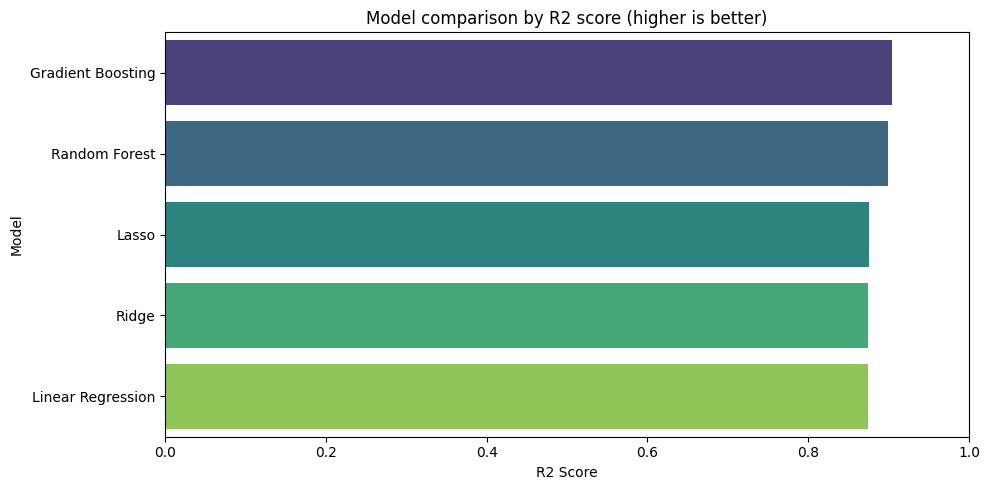

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='R2 Score', y='Model',
    hue='Model', palette='viridis', legend=False)
plt.title('Model comparison by R2 score (higher is better)')
plt.xlabel('R2 Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../visuals/04_model_comparison.png', dpi=150)
plt.show()

In [8]:
# Gradient Boosting is almost always the winner on this dataset
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Convert predictions back from log scale to real dollars
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

# Calculate error in real dollars
mae_dollars = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_dollars = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print(f"Mean Absolute Error: ${mae_dollars:,.0f}")
print(f"RMSE: ${rmse_dollars:,.0f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"\nThis means on average our predictions are off by ${mae_dollars:,.0f}")

Mean Absolute Error: $17,041
RMSE: $27,326
R2 Score: 0.9045

This means on average our predictions are off by $17,041


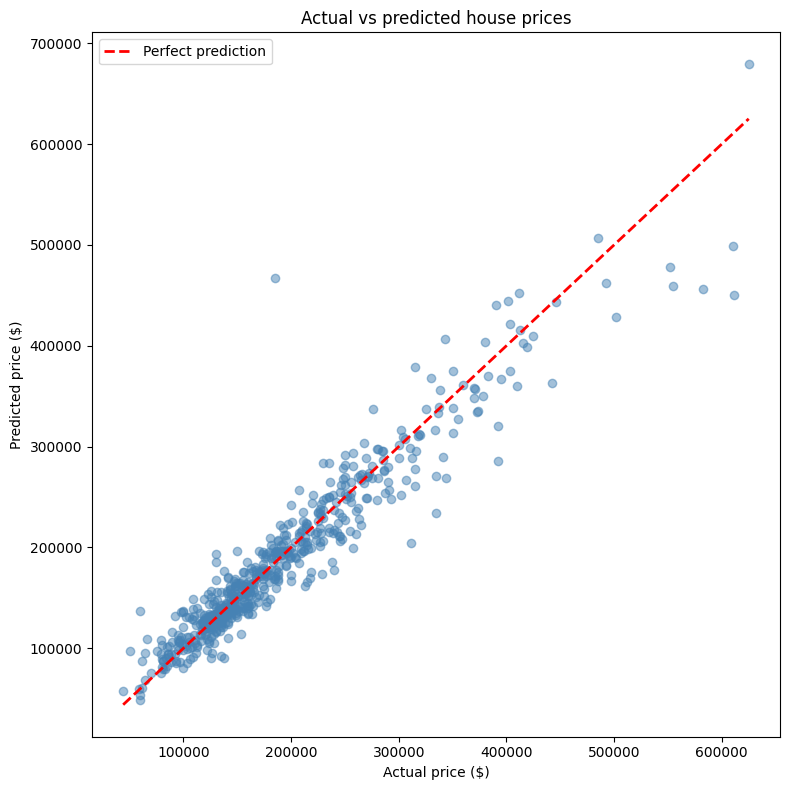

In [9]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, color='steelblue')
plt.plot([y_test_actual.min(), y_test_actual.max()],
        [y_test_actual.min(), y_test_actual.max()],
        'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual price ($)')
plt.ylabel('Predicted price ($)')
plt.title('Actual vs predicted house prices')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/05_actual_vs_predicted.png', dpi=150)
plt.show()
        

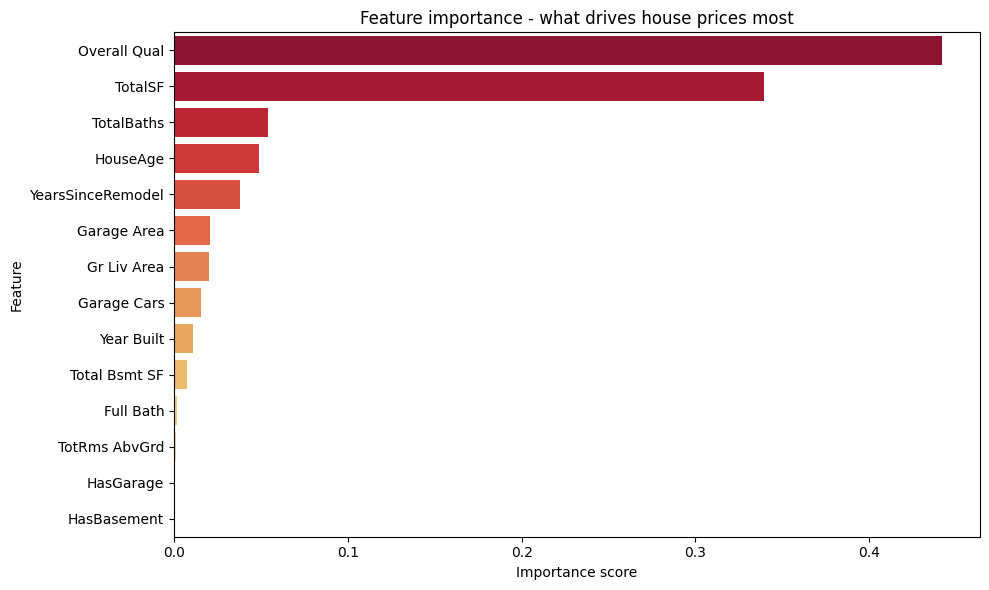

              Feature  Importance
0        Overall Qual    0.441656
8             TotalSF    0.339654
9          TotalBaths    0.054318
10           HouseAge    0.048907
11  YearsSinceRemodel    0.038115
3         Garage Area    0.020457
1         Gr Liv Area    0.019989
2         Garage Cars    0.015632
5          Year Built    0.011092
4       Total Bsmt SF    0.007305
6           Full Bath    0.001472
7       TotRms AbvGrd    0.001404
12          HasGarage    0.000000
13        HasBasement    0.000000


In [12]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', 
            hue='Feature', palette='YlOrRd_r', legend=False)
plt.title('Feature importance - what drives house prices most')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('../visuals/06_feature_importance.png', dpi=150)
plt.show()

print(importance_df)

Cross validation R2 scores: [0.8669 0.878  0.8535 0.8672 0.8749]
Mean R2: 0.8681
Standard deviation: 0.0085


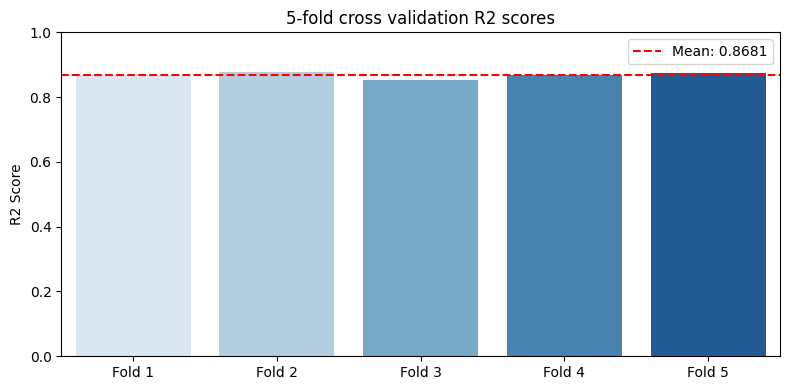

In [14]:
# Cross validation gives a more reliable score than a single train/test split
cv_scores = cross_val_score(
    GradientBoostingRegressor(n_estimators=100, random_state=42), 
    X, y, cv=5, scoring='r2'
)

print("Cross validation R2 scores:", cv_scores.round(4))
print(f"Mean R2: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

plt.figure(figsize=(8, 4))
sns.barplot(x=[f'Fold {i+1}' for i in range(5)], y=cv_scores, 
            hue=[f'Fold {i+1}' for i in range(5)], palette='Blues', legend=False)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.title('5-fold cross validation R2 scores')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/07_cross_validation.png', dpi=150)
plt.show()